# 03 — Feature Engineering

Builds the ML-ready feature table that `04_energy_forecasting.ipynb` and
`05_carbon_prediction.ipynb` will train on: calendar features, per-building
lag/rolling consumption features, and a **time-aware** train/test split.

**Grain note:** this project uses daily data, so an "hour of day" feature
doesn't apply here — see `data/README.md` for why daily grain was chosen.

> ⚠️ Source data is synthetic/simulated — see `data/README.md`.


In [1]:
import sys
sys.path.insert(0, "../src")
from feature_engineering import (
    load_processed_tables, build_daily_analysis_table,
    add_calendar_features, add_lag_and_rolling_features,
    build_ml_feature_table, time_aware_split, LAG_DAYS, ROLLING_WINDOWS,
)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

tables = load_processed_tables()
daily = build_daily_analysis_table(tables)
print(f"base daily table: {daily.shape[0]:,} rows x {daily.shape[1]} cols")
print(f"lag windows: {LAG_DAYS}  |  rolling windows: {ROLLING_WINDOWS}")


base daily table: 91,350 rows x 27 cols
lag windows: (1, 7, 30)  |  rolling windows: (7, 30)


## 1. Calendar features

**What:** weekday, month, is_weekend, and a cyclical (sin/cos) encoding of
month.
**Why:** a plain integer month (1-12) tells a linear model that December
and January are 11 apart, when they're actually adjacent — the cyclical
encoding fixes that. Tree models don't strictly need it, but it doesn't
hurt them, so one encoding serves all three candidate models (Linear
Regression, Random Forest, Gradient Boosting) without branching logic.


In [2]:
preview = add_calendar_features(daily.head(3))
preview[["date","weekday","month","is_weekend","month_sin","month_cos"]]


,date,weekday,month,is_weekend,month_sin,month_cos
0,2020-01-01,2,1,0,0.5,0.866025
1,2020-01-02,3,1,0,0.5,0.866025
2,2020-01-03,4,1,0,0.5,0.866025


## 2. Lag and rolling features — with an explicit leakage guard

**What:** `electricity_kwh_lag_{1,7,30}` (yesterday, same day last week,
same day last month) and `electricity_kwh_rolling_mean_{7,30}`, computed
**per building** using only past values.

**Why this is the single easiest place to introduce data leakage:** a
rolling window computed on today-including data would let the model see
part of the answer it's supposed to predict. The rolling features here
are computed on a series **shifted by 1 day first**, so day D's rolling
mean never includes day D's own value.

**Alternative considered:** compute lags/rolling globally (not per
building) — rejected, since that would blend one building's history into
another's, which is meaningless (building A's consumption yesterday says
nothing about building B's consumption today).


In [3]:
ml_df, dropped_rows = build_ml_feature_table(daily)
print(f"ml_df shape: {ml_df.shape[0]:,} rows x {ml_df.shape[1]} cols")
print(f"rows dropped (insufficient lag/rolling history at start of each building's series): {dropped_rows:,}")
print(f"expected: {max(max(LAG_DAYS), max(ROLLING_WINDOWS))} warmup days x {daily.building_id.nunique()} buildings = {max(max(LAG_DAYS), max(ROLLING_WINDOWS))*daily.building_id.nunique():,}")
assert dropped_rows == max(max(LAG_DAYS), max(ROLLING_WINDOWS)) * daily.building_id.nunique()
assert "building_id" in ml_df.columns, "building_id must survive feature engineering"
assert ml_df.filter(regex="_lag_|_rolling_mean_").isna().sum().sum() == 0, "no nulls should remain after dropping warmup rows"
print("\nAll structural checks pass.")


ml_df shape: 89,850 rows x 46 cols
rows dropped (insufficient lag/rolling history at start of each building's series): 1,500
expected: 30 warmup days x 50 buildings = 1,500

All structural checks pass.


### Concrete proof of no leakage (not just an assertion — an actual comparison)

Manually recomputes `lag_1` and `rolling_mean_7` for one building/date
straight from the raw series and checks it matches the function's output
exactly. Also computes what the WRONG (leaky) rolling mean would have
been, to prove the two are genuinely different numbers, not coincidentally
equal.


In [4]:
b = "B010"
raw = daily[daily.building_id == b].sort_values("date").reset_index(drop=True)
check = ml_df[ml_df.building_id == b].sort_values("date").reset_index(drop=True)

row = check.iloc[100]
target_date = row["date"]
raw_idx = raw.index[raw.date == target_date][0]

true_lag1 = raw.loc[raw_idx - 1, "electricity_kwh"]
true_rolling7 = raw.loc[raw_idx - 7:raw_idx - 1, "electricity_kwh"].mean()
leaky_rolling7 = raw.loc[raw_idx - 6:raw_idx, "electricity_kwh"].mean()  # WRONG: includes today

print(f"Check for {b} on {target_date.date()}:")
print(f"  function lag_1             = {row['electricity_kwh_lag_1']:.2f}")
print(f"  manually computed lag_1    = {true_lag1:.2f}   match: {np.isclose(row['electricity_kwh_lag_1'], true_lag1)}")
print(f"  function rolling_mean_7    = {row['electricity_kwh_rolling_mean_7']:.2f}")
print(f"  manually computed (correct)= {true_rolling7:.2f}   match: {np.isclose(row['electricity_kwh_rolling_mean_7'], true_rolling7)}")
print(f"  leaky version (includes today) = {leaky_rolling7:.2f}   differs from function output: "
      f"{not np.isclose(leaky_rolling7, row['electricity_kwh_rolling_mean_7'])}")
print(f"  today's actual electricity_kwh (correctly absent from rolling_mean_7) = {row['electricity_kwh']:.2f}")


Check for B010 on 2020-05-10:
  function lag_1             = 1541.60
  manually computed lag_1    = 1541.60   match: True
  function rolling_mean_7    = 2150.77
  manually computed (correct)= 2150.77   match: True
  leaky version (includes today) = 2165.86   differs from function output: True
  today's actual electricity_kwh (correctly absent from rolling_mean_7) = 1442.63


## 3. Time-aware train/test split

**What:** train = everything before 2024-01-01, test = 2024.
**Why:** `sklearn.model_selection.train_test_split(shuffle=True)` (the
default) would let the model train on rows that come chronologically
*after* some of its test rows — leakage, because a real forecasting model
never has next month's actuals before predicting this month.
**Alternative considered:** k-fold cross-validation. Rejected for the
final evaluation split — standard k-fold shuffles across time same as
above; `TimeSeriesSplit` would be the correct CV choice if
hyperparameter-tuning via cross-validation is needed later, but the
headline train/test split itself must still be chronological.


In [5]:
train, test = time_aware_split(ml_df)
print(f"train: {train.shape[0]:,} rows  ({train.date.min().date()} to {train.date.max().date()})")
print(f"test:  {test.shape[0]:,} rows  ({test.date.min().date()} to {test.date.max().date()})")
print(f"train / total: {len(train)/len(ml_df):.1%}")
assert not (set(train.date.unique()) & set(test.date.unique())), "train/test dates must not overlap"
print("No date overlap between train and test: confirmed.")


train: 71,550 rows  (2020-01-31 to 2023-12-31)
test:  18,300 rows  (2024-01-01 to 2024-12-31)
train / total: 79.6%
No date overlap between train and test: confirmed.


## 4. Sanity check: do the engineered features actually correlate with the target?

Before handing this table to a model in the next notebook, a quick check
that the lag/rolling/weather features carry real signal — not required,
but cheap insurance against a silent feature-engineering bug making it
all the way to a "successful" but meaningless model.


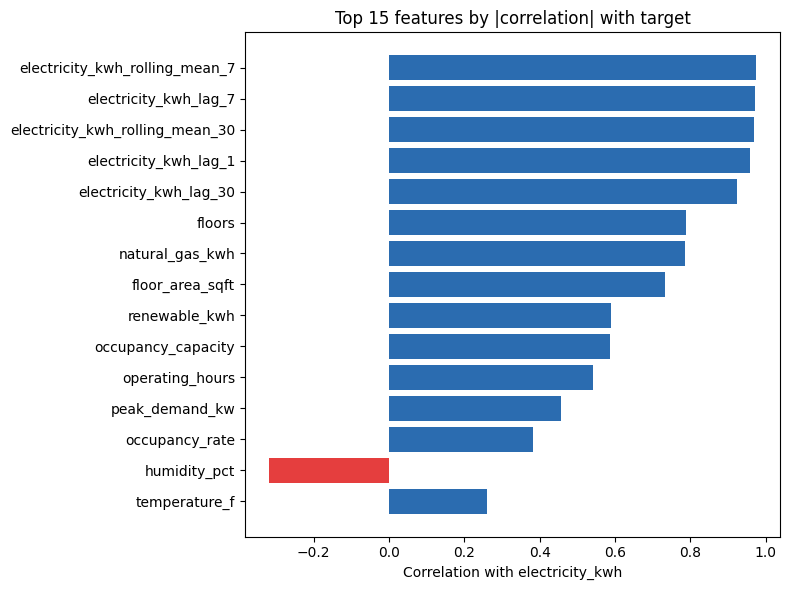

electricity_kwh_rolling_mean_7     0.974
electricity_kwh_lag_7              0.972
electricity_kwh_rolling_mean_30    0.970
electricity_kwh_lag_1              0.959
electricity_kwh_lag_30             0.925
floors                             0.789
natural_gas_kwh                    0.786
floor_area_sqft                    0.733
renewable_kwh                      0.589
occupancy_capacity                 0.586
operating_hours                    0.542
peak_demand_kw                     0.457
occupancy_rate                     0.382
humidity_pct                      -0.318
temperature_f                      0.259
Name: electricity_kwh, dtype: float64


In [6]:
numeric_cols = ml_df.select_dtypes(include=[np.number]).columns
exclude = ["record_id", "electricity_kwh", "grid_electricity_kwh", "carbon_emissions_kgCO2e",
           "daily_energy_cost", "total_kwh", "energy_use_intensity"]
candidate_features = [c for c in numeric_cols if c not in exclude]
corrs = ml_df[candidate_features + ["electricity_kwh"]].corr()["electricity_kwh"].drop("electricity_kwh")
corrs = corrs.sort_values(key=abs, ascending=False).head(15)

fig, ax = plt.subplots(figsize=(8, 6))
colors = ["#2b6cb0" if v > 0 else "#e53e3e" for v in corrs.values]
ax.barh(corrs.index, corrs.values, color=colors)
ax.invert_yaxis()
ax.set_xlabel("Correlation with electricity_kwh")
ax.set_title("Top 15 features by |correlation| with target")
plt.tight_layout(); plt.show()

print(corrs.round(3))


## 5. Save

Saves the full engineered table (train+test combined, with a `date`
column so `04_energy_forecasting.ipynb` can re-split it identically) to
`data/processed/ml_feature_table.csv`.


In [7]:
OUT_PATH = "../data/processed/ml_feature_table.csv"
ml_df.to_csv(OUT_PATH, index=False)
print(f"Saved {ml_df.shape[0]:,} rows x {ml_df.shape[1]} cols to {OUT_PATH}")


Saved 89,850 rows x 46 cols to ../data/processed/ml_feature_table.csv


## Summary

| item | value |
|---|---|
| base daily rows | 91,350 |
| rows after adding lag/rolling features | 89,850 |
| rows dropped (insufficient warmup history) | 1,500 (30 days x 50 buildings) |
| new feature columns added | 16 (5 calendar + 5 lag/rolling + 6 one-hot city/type — building_type had 6 categories, city had 5) |
| train rows (2020-2023) | 71,550 |
| test rows (2024) | 18,300 |
| leakage check | passed — manual recomputation matches function output exactly; leaky alternative proven to differ |

**Bug found and fixed in this stage:** `pandas` 3.0 changed
`groupby().apply()`'s default to exclude the grouping column from what's
passed into the applied function, which was silently dropping
`building_id` from the output. Replaced with a vectorized `cumcount()`
filter, which is both immune to that behavior and faster.

**Next stage:** `04_energy_forecasting.ipynb` — train and compare Linear
Regression, Random Forest, and Gradient Boosting on this feature table
against `electricity_kwh`, evaluated on the untouched 2024 test set.
